## Model Training
---

In [1]:
# importing the required libraries library 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# reading the dataset csv file that will required for model training
df = pd.read_csv('..\\datasets\\loan_data_cleaned.csv')

df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,3,71948.0,0,35000.0,16.02,0.49,3.0,561,0,1,False,False,True,False,False,False,True,False
1,21.0,0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,False,True,False,True,False,False,False,False
2,25.0,0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,1,False,False,False,False,False,True,False,False
3,23.0,0,2,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,False,False,True,False,False,True,False,False
4,24.0,1,3,66135.0,1,35000.0,14.27,0.53,4.0,586,0,1,False,False,True,False,False,True,False,False


In [3]:
from sklearn.model_selection import train_test_split

# Define X by dropping target columns and redundant features
X =  df.drop("loan_status", axis=1)
y = df['loan_status']

# Split the data (80% for training and 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# display the shape of training and testing data
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (36000, 19)
Testing features shape: (9000, 19)


In [5]:
from sklearn.ensemble import RandomForestClassifier

# initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# train the model using the training data
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Confusion Matrix:
[[6815  175]
 [ 450 1560]]


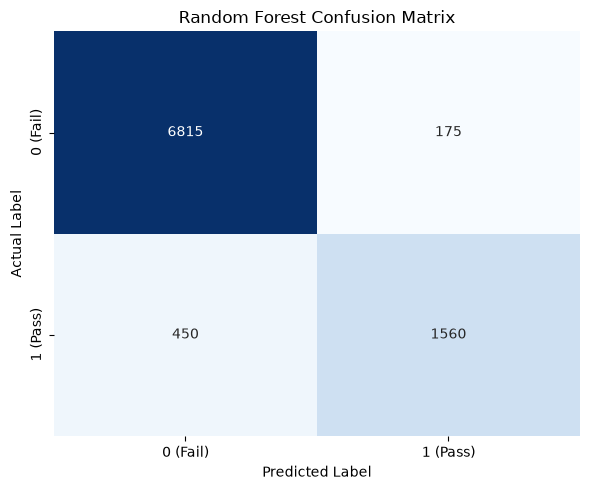

In [7]:
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Prediction probabilities (Optional - useful for ROC Curve)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['0 (Fail)', '1 (Pass)'],
    yticklabels=['0 (Fail)', '1 (Pass)']
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

print("\nClassification Report: ")
print(classification_report(y_test, y_pred))

print("Performance Summary: ")
print(f"Overall Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:         {roc_auc_score(y_test, y_pred_proba):.4f}")


Classification Report: 
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      6990
           1       0.90      0.78      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.88      0.89      9000
weighted avg       0.93      0.93      0.93      9000

Performance Summary: 
Overall Test Accuracy: 0.9306
ROC-AUC Score:         0.9741


                           Feature  Importance
10  previous_loan_defaults_on_file    0.207116
7              loan_percent_income    0.178310
6                    loan_int_rate    0.158378
3                    person_income    0.122767
13      person_home_ownership_RENT    0.061536
5                        loan_amnt    0.058020
9                     credit_score    0.055062
0                       person_age    0.030564
4                   person_emp_exp    0.027623
8       cb_person_cred_hist_length    0.025228
2                 person_education    0.016881
12       person_home_ownership_OWN    0.010578
15     loan_intent_HOMEIMPROVEMENT    0.009365
18             loan_intent_VENTURE    0.008097
1                    person_gender    0.007797
14           loan_intent_EDUCATION    0.007745
16             loan_intent_MEDICAL    0.007342
17            loan_intent_PERSONAL    0.006918
11     person_home_ownership_OTHER    0.000675


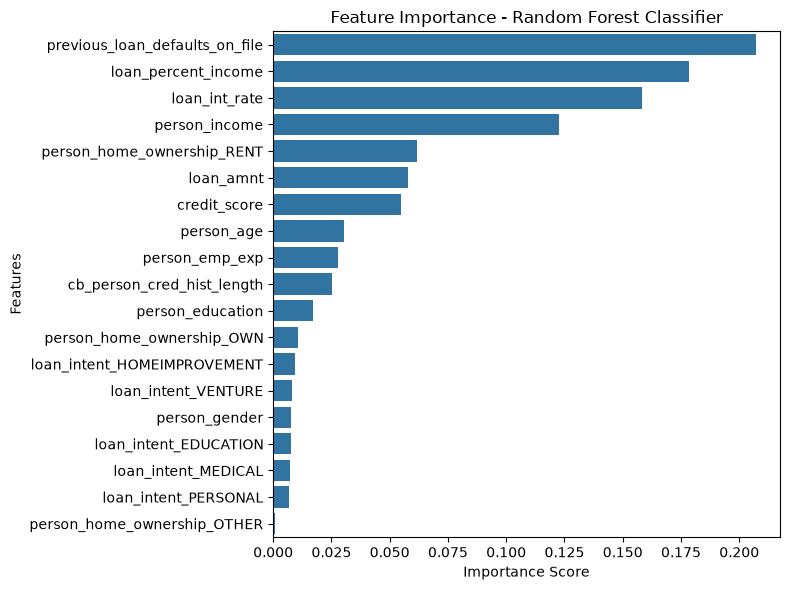

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(8,6))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest Classifier")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()